In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = gpd.read_parquet('../data/processed/bairros_dti.parquet')

df = df.set_crs('EPSG:4326')

print(f"Shape: {df.shape}")
print(f"CRS: {df.crs}")
print(f"\nDTI - estatísticas:")
print(df['DTI'].describe().round(2))

Shape: (164, 15)
CRS: EPSG:4326

DTI - estatísticas:
count    164.00
mean      48.87
std        8.39
min       26.19
25%       45.20
50%       48.59
75%       52.94
max       79.75
Name: DTI, dtype: float64


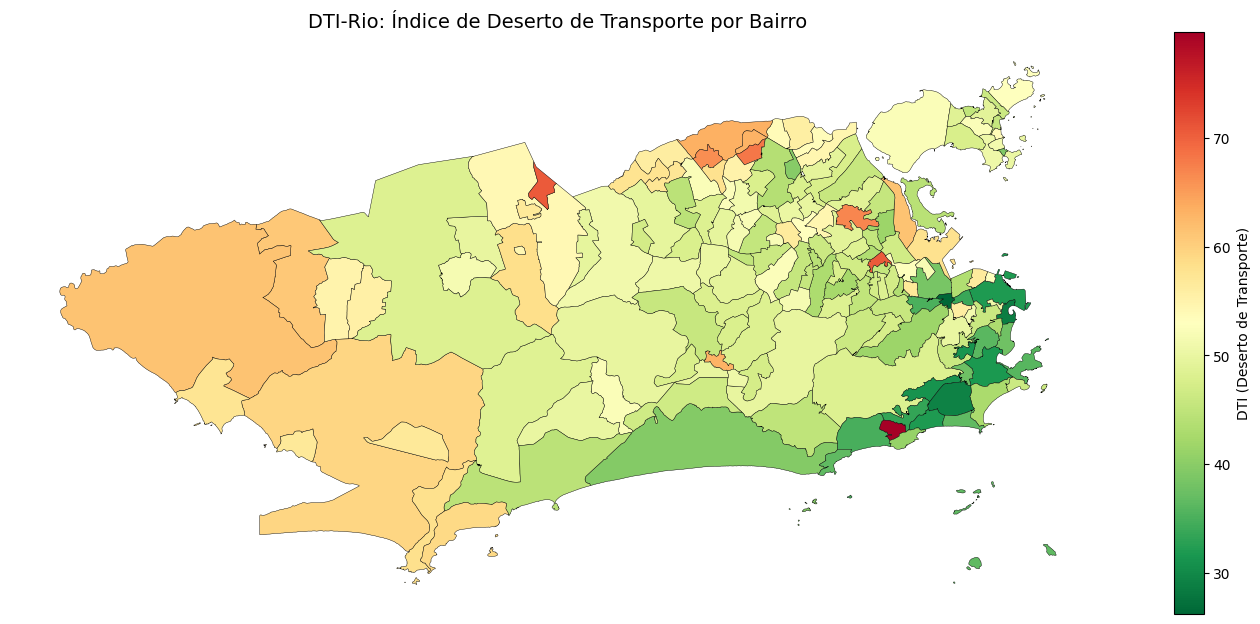

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

df.plot(
    column='DTI',
    cmap='RdYlGn_r',          # Verde (DTI baixo) → Vermelho (DTI alto / deserto)
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    ax=ax,
    legend_kwds={'label': 'DTI (Deserto de Transporte)', 'shrink': 0.6}
)

ax.set_title('DTI-Rio: Índice de Deserto de Transporte por Bairro', fontsize=14)
ax.set_axis_off()  # Remove os eixos lat/long 
plt.tight_layout()
plt.show()

In [13]:
import folium
from folium.features import GeoJsonTooltip

In [ ]:
# Centroide do Rio para centralizar o mapa
centro_rio = [-22.91, -43.40]

m = folium.Map(
    location=centro_rio,
    zoom_start=11,
    tiles='cartodbpositron'  # mapa base limpo, sem ruído
)

df_plot = df.copy()
df_plot['DTI'] = df_plot['DTI'].fillna(-1)  # placeholder pros NaN
df_plot['headway_medio_min'] = df_plot['headway_medio_min'].fillna(0)

folium.Choropleth(
    geo_data=df_plot.__geo_interface__,
    name='DTI',
    data=df_plot,
    columns=['bairro', 'DTI'],
    key_on='feature.properties.bairro',
    fill_color='RdYlGn_r',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='DTI - Deserto de Transporte (0 = bem servido, 100 = deserto)',
    nan_fill_color='lightgrey',
    nan_fill_opacity=0.4,
    bins=[26, 38, 46, 52, 60, 80]  # 5 categorias baseadas nos quartis
).add_to(m)

tooltip_layer = folium.GeoJson(
    df_plot,
    style_function=lambda x: {'fillOpacity': 0, 'color': 'transparent'},
    tooltip=GeoJsonTooltip(
        fields=['bairro', 'regiao_adm', 'DTI', 'ips', 'cobertura_400m', 'n_paradas'],
        aliases=['Bairro:', 'Região Adm:', 'DTI:', 'IPS:', 'Cobertura 400m:', 'Nº de paradas:'],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: white;
            border: 1px solid grey;
            border-radius: 3px;
            padding: 6px;
            font-size: 12px;
        """
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save('reports/mapa_dti_interativo.html')